In [123]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

Общая загрузка

In [124]:
#1. Загрузить CSV-файл и вывести первые 10 строк.
df = pd.read_csv('TelcoCustomers.csv')

#2. Посмотреть .info() и .shape.
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


(7043, 21)

In [125]:
#3. Проверить уникальные значения по object-признакам.
obj_columns = df.select_dtypes(include='object').columns
for i in obj_columns:
    print(f"{i}: {df[i].unique()}")

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn: ['No' 'Yes']


In [126]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [127]:
# Меняем пробелы (' ') на NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mode()[0])

for i in df.columns:
    print(f"{i} (пробелы): {(df[i] == ' ').sum()}")

print(f"TotalCharges (NaN): {df['TotalCharges'].isna().sum()}")

customerID (пробелы): 0
gender (пробелы): 0
SeniorCitizen (пробелы): 0
Partner (пробелы): 0
Dependents (пробелы): 0
tenure (пробелы): 0
PhoneService (пробелы): 0
MultipleLines (пробелы): 0
InternetService (пробелы): 0
OnlineSecurity (пробелы): 0
OnlineBackup (пробелы): 0
DeviceProtection (пробелы): 0
TechSupport (пробелы): 0
StreamingTV (пробелы): 0
StreamingMovies (пробелы): 0
Contract (пробелы): 0
PaperlessBilling (пробелы): 0
PaymentMethod (пробелы): 0
MonthlyCharges (пробелы): 0
TotalCharges (пробелы): 0
Churn (пробелы): 0
TotalCharges (NaN): 0


In [128]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [129]:
df['TotalCharges'] = df['TotalCharges'].astype(float)

In [130]:
df['TotalCharges'].dtype

dtype('float64')

******************************************

*******************************************************

Pandas-практика

In [131]:
#7. Средний tenure, MonthlyCharges, TotalCharges.
print(f"Средний tenure: {(df['tenure']).mean()}")
print(f"Средний MonthlyCharges: {(df['MonthlyCharges']).mean()}")
print(f"Средний TotalCharges: {(df['TotalCharges']).mean()}")

Средний tenure: 32.37114865824223
Средний MonthlyCharges: 64.76169246059918
Средний TotalCharges: 2279.7658526196224


In [132]:
# 8. Распределение по Contract, InternetService, Churn — value_counts().
print('-----------------------------------------------------------------------------')
print(f"Распределение Contract: {(df['Contract']).value_counts()}")
print('-----------------------------------------------------------------------------')
print(f"Распределение InternetService: {(df['InternetService']).value_counts()}")
print('-----------------------------------------------------------------------------')
print(f"Распределение Churn : {(df['Churn']).value_counts()}")
print('-----------------------------------------------------------------------------')

-----------------------------------------------------------------------------
Распределение Contract: Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64
-----------------------------------------------------------------------------
Распределение InternetService: InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64
-----------------------------------------------------------------------------
Распределение Churn : Churn
No     5174
Yes    1869
Name: count, dtype: int64
-----------------------------------------------------------------------------


In [133]:
#9. Средние показатели по группам Churn.
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.954387
Yes,17.979133,74.441332,1531.796094


In [134]:
#10. Количество клиентов с tenure < 3 месяцев.
print(f"Количество клиентов с tenure < 3 месяцев: {df[df['tenure'] < 3].shape[0]}")

Количество клиентов с tenure < 3 месяцев: 862


In [135]:
#11. Доля клиентов с MonthlyCharges > 100.
print(f"Доля клиентов с MonthlyCharges > 100: {len(df[df['MonthlyCharges'] > 100]) / len(df)}")

Доля клиентов с MonthlyCharges > 100: 0.12807042453499928


In [136]:
#12. Группировка по Contract — средний TotalCharges.
print(f"средний TotalCharges: {df.groupby('Contract')['TotalCharges'].mean()}")

средний TotalCharges: Contract
Month-to-month    1369.254581
One year          3032.636592
Two year          3707.053510
Name: TotalCharges, dtype: float64


*******************************************************

**************************************************

Визуализация

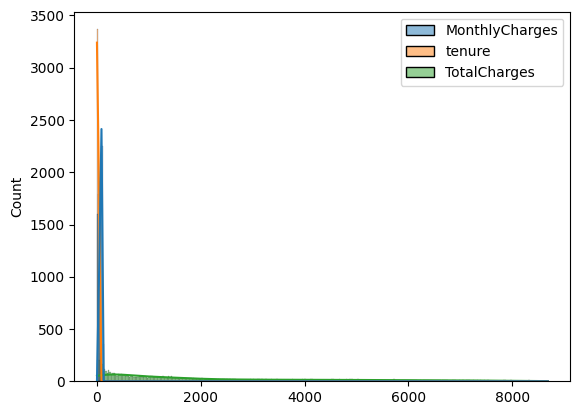

In [137]:
#13. hist / distplot по MonthlyCharges, tenure, TotalCharges.
sns.histplot(df[['MonthlyCharges', 'tenure', 'TotalCharges']], kde=True)
plt.show()

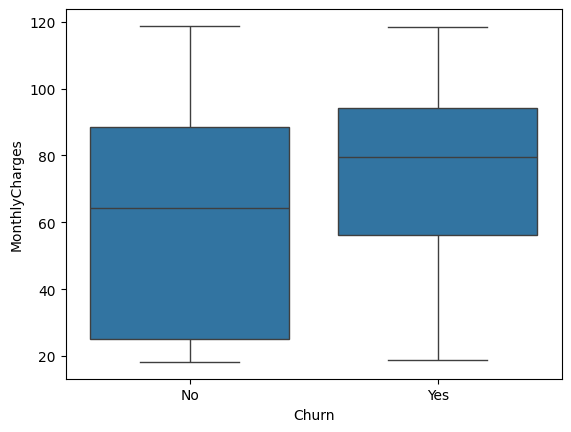

In [138]:
#14. boxplot: Churn vs MonthlyCharges.
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.show()

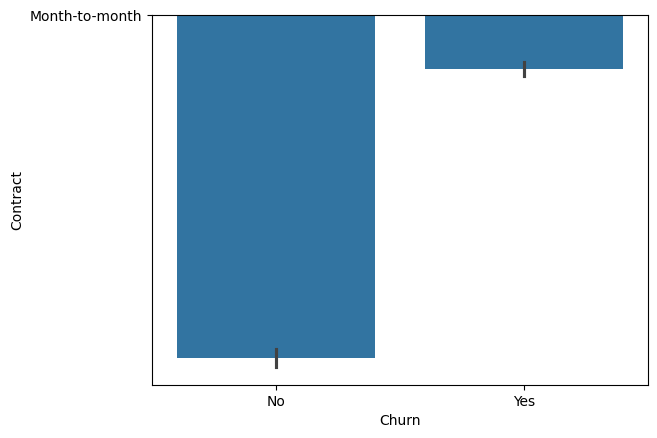

In [139]:
#15. barplot: Churn vs Contract.
sns.barplot(data=df, x='Churn', y='Contract')
plt.show()

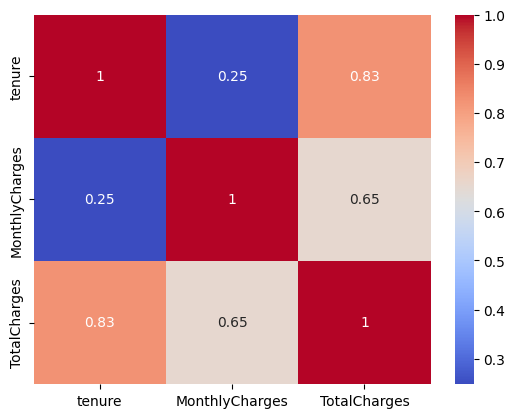

In [140]:
#16. heatmap корреляций числовых признаков.
sns.heatmap(data=df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm')
plt.show()

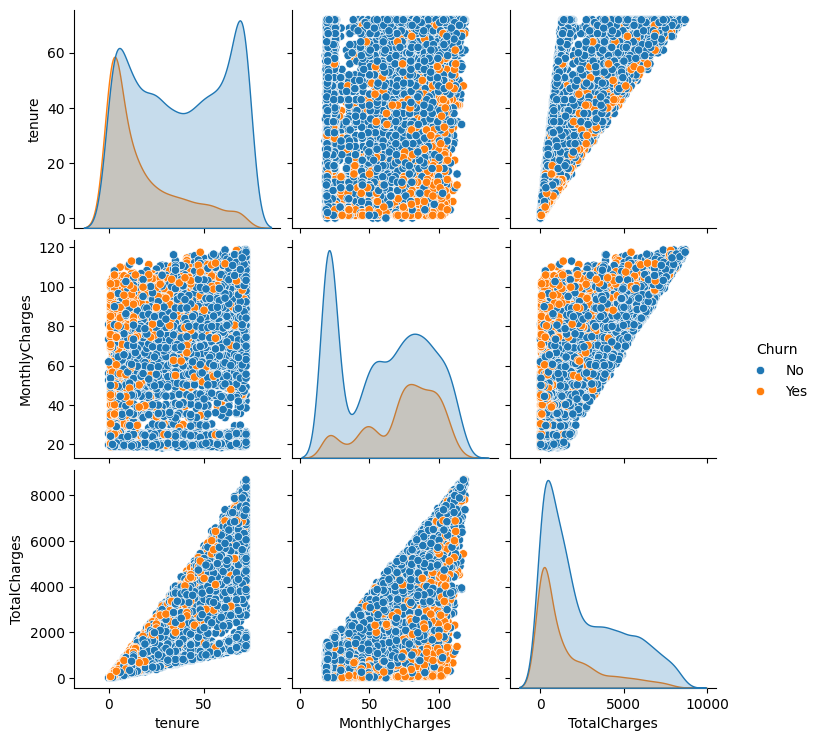

In [141]:
#17. pairplot по числовым признакам + Churn.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
df_subset = df[numeric_cols]
sns.pairplot(data=df_subset, hue='Churn')
plt.show()

Предобработка

In [142]:
#18. Проверить пропущенные значения и заполнить/удалить.
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [144]:
df1 = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'OnlineSecurity', 'TechSupport', 'Churn']]

In [145]:
df1

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,OnlineSecurity,TechSupport,Churn
0,1,29.85,29.85,Month-to-month,DSL,No,No,No
1,34,56.95,1889.50,One year,DSL,Yes,No,No
2,2,53.85,108.15,Month-to-month,DSL,Yes,No,Yes
3,45,42.30,1840.75,One year,DSL,Yes,Yes,No
4,2,70.70,151.65,Month-to-month,Fiber optic,No,No,Yes
...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,One year,DSL,Yes,Yes,No
7039,72,103.20,7362.90,One year,Fiber optic,No,No,No
7040,11,29.60,346.45,Month-to-month,DSL,Yes,No,No
7041,4,74.40,306.60,Month-to-month,Fiber optic,No,No,Yes


In [146]:
# Бинарный кодировка
df1['Churn'] = df1['Churn'].map({'No': 0, 'Yes': 1})

/tmp/ipykernel_555/2968872941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Churn'] = df1['Churn'].map({'No': 0, 'Yes': 1})


In [147]:
df1['Churn'].unique()

array([0, 1])

In [148]:
#19. Кодировка категориальных признаков (Contract, InternetService, OnlineSecurity, TechSupport, Churn) с помощью: LabelEncoder или OneHotEncoder для моделей.
# get_dummies трогает только эти 4 столбца, но .astype(int) в конце цепочки применяется уже ко всему датафрейму целиком, включая MonthlyCharges и TotalCharges, по этому отдельно указали что эти float
df1 = pd.get_dummies(df1, columns=['Contract', 'InternetService', 'OnlineSecurity', 'TechSupport'], drop_first=True).astype({'MonthlyCharges': float, 'TotalCharges': float})

In [149]:
# не трогаем 'MonthlyCharges' и 'TotalCharges', а остальных преобразуем в int
for col in df1.columns:
    if col not in ['MonthlyCharges', 'TotalCharges']:
        df1[col] = df1[col].astype(int)

In [150]:
df1

,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes
0,1,29.85,29.85,0,0,0,0,0,0,0,0,0
1,34,56.95,1889.50,0,1,0,0,0,0,1,0,0
2,2,53.85,108.15,1,0,0,0,0,0,1,0,0
3,45,42.30,1840.75,0,1,0,0,0,0,1,0,1
4,2,70.70,151.65,1,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7038,24,84.80,1990.50,0,1,0,0,0,0,1,0,1
7039,72,103.20,7362.90,0,1,0,1,0,0,0,0,0
7040,11,29.60,346.45,0,0,0,0,0,0,1,0,0
7041,4,74.40,306.60,1,0,0,1,0,0,0,0,0


In [151]:
# 20. Масштабирование числовых признаков (StandardScaler).
scaler = StandardScaler()
features = df1.drop(columns=['Churn'])
scaled_data = scaler.fit_transform(features)

In [152]:
#21. Разделить данные на X и y (где y = Churn).
x = scaled_data
y = df['Churn']

In [153]:
# 22. Разделить выборку на train/test (80/20).
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

ЭТАП 3: Обучение моделей

3.1 Логистическая регрессия

In [154]:
#23. Обучить LogisticRegression() на обучающей выборке.
model_lg = LogisticRegression()
model_lg.fit(x_train, y_train)

LogisticRegression()

In [155]:
#24. Сделать предсказание на тесте.
y_predict_lg = model_lg.predict(x_test)
y_predict_lg

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [156]:
#26. Вывести коэффициенты модели.
importances = model_rf.feature_importances_
features = X_train.columns if 'X_train' in locals() else df1.drop(columns=['Churn']).columns

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

                               Feature  Importance
2                         TotalCharges    0.311902
1                       MonthlyCharges    0.292918
0                               tenure    0.207503
5          InternetService_Fiber optic    0.053015
4                    Contract_Two year    0.039611
3                    Contract_One year    0.024565
8                   OnlineSecurity_Yes    0.023076
10                     TechSupport_Yes    0.019075
9      TechSupport_No internet service    0.012237
7   OnlineSecurity_No internet service    0.008397
6                   InternetService_No    0.007701


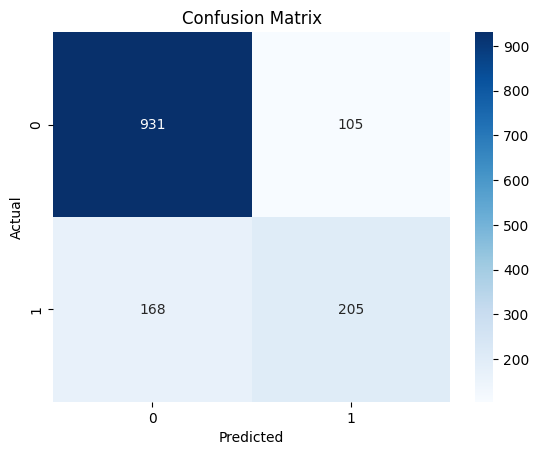

In [157]:
cm = confusion_matrix(y_test, y_predict_lg)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')  # fmt='d' лучше для целых чисел
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

3.2 Дерево решений

In [158]:
#27. Обучить DecisionTreeClassifier() на той же выборке.
model_tree = DecisionTreeClassifier(criterion = 'gini', max_depth = 1, min_samples_leaf = 1, min_samples_split = 2)
model_tree.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=1)

In [159]:
#28. Сделать предсказание на тесте.
y_predict_tree = model_tree.predict(x_test)
y_predict_tree

array(['No', 'No', 'No', ..., 'No', 'No', 'No'], dtype=object)

In [160]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(random_state=42)

# param_grid = {
#     'max_depth' : [1,2,3,4,5,6,7,8,9,10,None],
#     'min_samples_split' : [2,3,4,5,6,7,8,9,10],
#     'min_samples_leaf' : [1,2,3,4,5,6,7,8,9,10],
#     'criterion' : ['gini', 'entropy']
# }

# grid_search = GridSearchCV(
#     estimator=dt,
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=1
# )
# grid_search.fit(x_train, y_train)
# print('Лучший параметр: ', grid_search.best_params_)

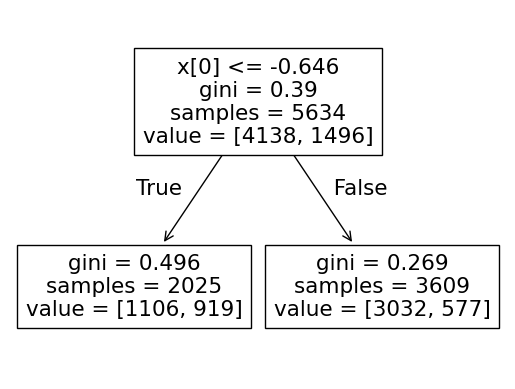

In [161]:
#29. Построить дерево (с помощью plot_tree() или export_graphviz).
plot_tree(model_tree)
plt.show()

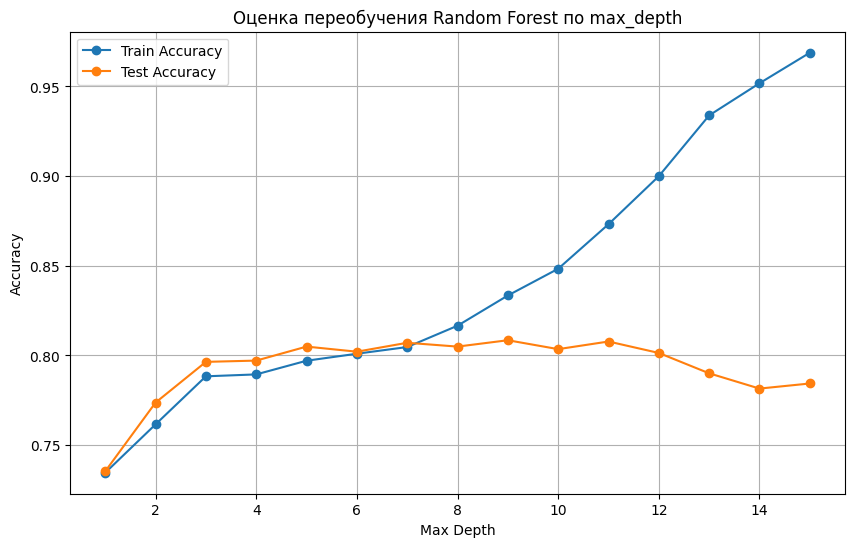

In [162]:
#30. Оценить переобучение по глубине дерева (max_depth).
train_scores = []
test_scores = []
depths = range(1, 16)  # Проверяем глубину от 1 до 15

for depth in depths:
    # Инициализируем модель с фиксированной глубиной
    model = RandomForestClassifier(max_depth=depth, random_state=42, n_jobs=-1)
    model.fit(x_train, y_train)

    # Считаем точность
    train_scores.append(accuracy_score(y_train, model.predict(x_train)))
    test_scores.append(accuracy_score(y_test, model.predict(x_test)))

# Строим график для анализа
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Оценка переобучения Random Forest по max_depth')
plt.legend()
plt.grid(True)
plt.show()

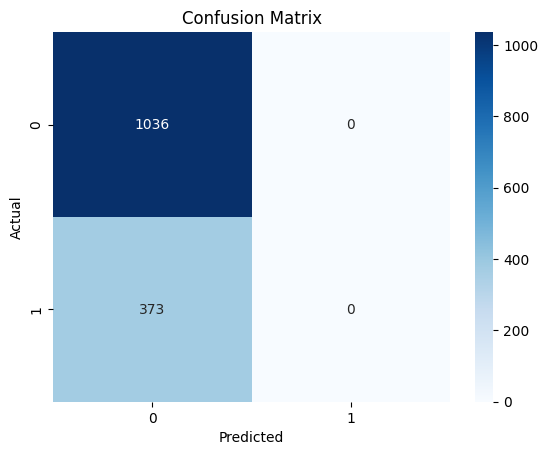

In [163]:
cm = confusion_matrix(y_test, y_predict_tree)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

3.3 Рандом Форест

In [164]:
model_rf = RandomForestClassifier()
model_rf.fit(x_train, y_train)

RandomForestClassifier()

In [165]:
# 31. Сделать предсказание на тесте.
y_predict_rf = model_rf.predict(x_test)
y_predict_rf

array(['Yes', 'No', 'No', ..., 'No', 'No', 'Yes'], dtype=object)

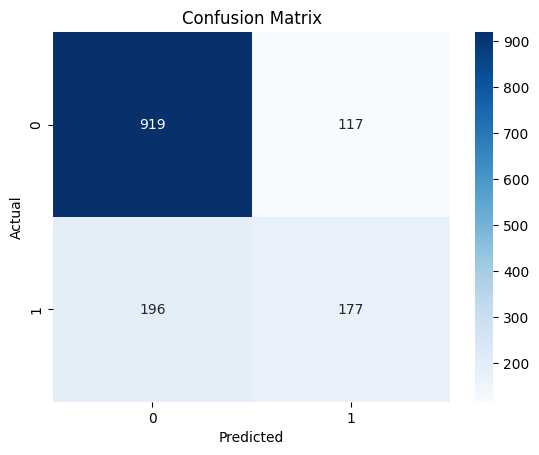

In [166]:
cm = confusion_matrix(y_test, y_predict_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [167]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.ensemble import RandomForestClassifier

# param_grid_rf = {
#     'n_estimators': [50, 100, 150, 175, 200],
#     'max_depth' : [1,3,5,7,10,None],
#     'min_samples_split' : [2,3,4,5,6],
#     'min_samples_leaf' : [1,2,3,4,5],
#     'criterion' : ['gini', 'entropy']
# }

# grid_rf = GridSearchCV(
#     estimator=RandomForestClassifier(random_state=42),
#     param_grid=param_grid_rf,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=1
# )

# grid_rf.fit(x_train, y_train)

# print('Лучший параметр случайного леса: ', grid_rf.best_params_)

In [168]:
# criterion = 'gini', max_depth = 10, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 100

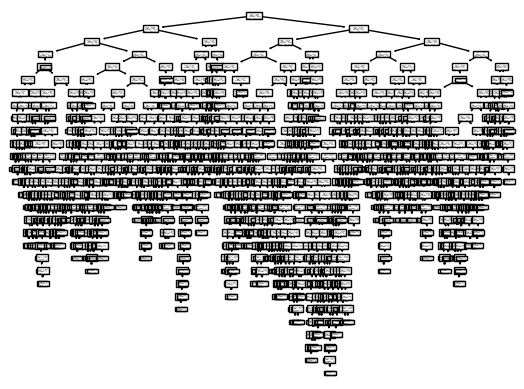

In [169]:
# Визуализация первого дерева из леса
plot_tree(model_rf.estimators_[0])
plt.show()

ЭТАП 4: Сравнение моделей

In [170]:
print('accuracy_score:')
print(f'Model Log: {accuracy_score(y_test, y_predict_lg)}')
print(f'Model Tree: {accuracy_score(y_test, y_predict_tree)}')
print(f'Model Rf: {accuracy_score(y_test, y_predict_rf)}')

accuracy_score:
Model Log: 0.8062455642299503
Model Tree: 0.7352732434350603
Model Rf: 0.7778566359119943


In [171]:
print('precision_score:')
print(f'Model Log Precision: {precision_score(y_test, y_predict_lg, pos_label="Yes")}')
print(f'Model Log Recall: {recall_score(y_test, y_predict_lg, pos_label="Yes")}')
print(f'Model Log F1: {f1_score(y_test, y_predict_lg, pos_label="Yes")}')

precision_score:
Model Log Precision: 0.6612903225806451
Model Log Recall: 0.5495978552278821
Model Log F1: 0.6002928257686676


In [172]:
print('recall_score:')
print(f'Model Tree Precision: {precision_score(y_test, y_predict_tree, pos_label="Yes")}')
print(f'Model Tree Recall: {recall_score(y_test, y_predict_tree, pos_label="Yes")}')
print(f'Model Tree F1: {f1_score(y_test, y_predict_tree, pos_label="Yes")}')

recall_score:
Model Tree Precision: 0.0
Model Tree Recall: 0.0
Model Tree F1: 0.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [173]:
print('f1_score:')
print(f'Model RF Precision: {precision_score(y_test, y_predict_rf, pos_label="Yes")}')
print(f'Model RF Recall: {recall_score(y_test, y_predict_rf, pos_label="Yes")}')
print(f'Model RF F1: {f1_score(y_test, y_predict_rf, pos_label="Yes")}')

f1_score:
Model RF Precision: 0.6020408163265306
Model RF Recall: 0.4745308310991957
Model RF F1: 0.5307346326836582


In [174]:
print('classification_report:')
print(f'Model Log: {classification_report(y_test, y_predict_lg)}')
print(f'Model Tree: {classification_report(y_test, y_predict_tree)}')
print(f'Model Rf: {classification_report(y_test, y_predict_rf)}')

classification_report:
Model Log:               precision    recall  f1-score   support

          No       0.85      0.90      0.87      1036
         Yes       0.66      0.55      0.60       373

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Model Tree:               precision    recall  f1-score   support

          No       0.74      1.00      0.85      1036
         Yes       0.00      0.00      0.00       373

    accuracy                           0.74      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.74      0.62      1409

Model Rf:               precision    recall  f1-score   support

          No       0.82      0.89      0.85      1036
         Yes       0.60      0.47      0.53       373

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [175]:
joblib.dump(model_rf, 'model_rf_TelcoCustomers.pkl')
joblib.dump(scaler, 'scaler_TelcoCustomers.pkl')

['scaler_TelcoCustomers.pkl']

In [176]:
df1.head()

,tenure,MonthlyCharges,TotalCharges,Churn,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,TechSupport_No internet service,TechSupport_Yes
0,1,29.85,29.85,0,0,0,0,0,0,0,0,0
1,34,56.95,1889.50,0,1,0,0,0,0,1,0,0
2,2,53.85,108.15,1,0,0,0,0,0,1,0,0
3,45,42.30,1840.75,0,1,0,0,0,0,1,0,1
4,2,70.70,151.65,1,0,0,1,0,0,0,0,0


In [177]:
df1.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'Contract_One year', 'Contract_Two year', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'TechSupport_No internet service',
       'TechSupport_Yes'],
      dtype='object')